In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/cleaned_transactions.csv")

In [2]:
df.head()
df["sender_state"].nunique()
df["sender_state"].unique()

array(['Delhi', 'Uttar Pradesh', 'Karnataka', 'Telangana', 'Maharashtra',
       'Gujarat', 'Rajasthan', 'Tamil Nadu', 'West Bengal',
       'Andhra Pradesh'], dtype=object)

In [4]:
#State-wise Transaction Count
state_transactions = (
    df.groupby("sender_state")
      .size()
      .reset_index(name="transaction_count")
      .sort_values(
          "transaction_count",
          ascending=False
      )
)

state_transactions.head(10)

,sender_state,transaction_count
4,Maharashtra,37427
8,Uttar Pradesh,30125
3,Karnataka,29756
6,Tamil Nadu,25367
1,Delhi,24870
7,Telangana,22435
2,Gujarat,20061
0,Andhra Pradesh,20006
5,Rajasthan,19981
9,West Bengal,19972


In [5]:
#State-wise Transaction Volume
state_volume = (
    df.groupby("sender_state")["amount_inr"]
      .sum()
      .reset_index(name="total_volume")
      .sort_values(
          "total_volume",
          ascending=False
      )
)

state_volume.head(10)

,sender_state,total_volume
4,Maharashtra,49043948
8,Uttar Pradesh,40035717
3,Karnataka,38451158
6,Tamil Nadu,33343518
1,Delhi,32689865
7,Telangana,29750930
5,Rajasthan,26730470
2,Gujarat,25988190
0,Andhra Pradesh,25952619
9,West Bengal,25952594


In [6]:
#Average Transaction Value by State
state_avg = (
    df.groupby("sender_state")["amount_inr"]
      .mean()
      .reset_index(name="avg_transaction")
      .sort_values(
          "avg_transaction",
          ascending=False
      )
)

state_avg.head(10)

,sender_state,avg_transaction
5,Rajasthan,1337.794405
8,Uttar Pradesh,1328.986456
7,Telangana,1326.094495
6,Tamil Nadu,1314.444672
1,Delhi,1314.429634
4,Maharashtra,1310.389505
9,West Bengal,1299.448928
0,Andhra Pradesh,1297.241777
2,Gujarat,1295.458352
3,Karnataka,1292.215284


In [7]:
#State-wise Success Rate
state_success = (
    df.groupby("sender_state")["transaction_status"]
      .apply(
          lambda x:
          (x == "Success").mean() * 100
      )
      .reset_index(name="success_rate")
      .sort_values(
          "success_rate",
          ascending=False
      )
)

state_success.head()

,sender_state,success_rate
0,Andhra Pradesh,0.0
1,Delhi,0.0
2,Gujarat,0.0
3,Karnataka,0.0
4,Maharashtra,0.0


In [8]:
#State-wise Failure Rate
state_failure = (
    df.groupby("sender_state")["transaction_status"]
      .apply(
          lambda x:
          (x == "Failed").mean() * 100
      )
      .reset_index(name="failure_rate")
      .sort_values(
          "failure_rate",
          ascending=False
      )
)

state_failure.head()

,sender_state,failure_rate
0,Andhra Pradesh,0.0
1,Delhi,0.0
2,Gujarat,0.0
3,Karnataka,0.0
4,Maharashtra,0.0


In [9]:
#Fraud Hotspots
fraud_hotspots = (
    df.groupby("sender_state")["fraud_flag"]
      .sum()
      .reset_index(name="fraud_count")
      .sort_values(
          "fraud_count",
          ascending=False
      )
)

fraud_hotspots.head(10)

,sender_state,fraud_count
4,Maharashtra,71
3,Karnataka,69
8,Uttar Pradesh,52
1,Delhi,50
5,Rajasthan,46
2,Gujarat,43
6,Tamil Nadu,40
7,Telangana,39
0,Andhra Pradesh,35
9,West Bengal,35


In [10]:
#Fraud Rate by State
fraud_rate_state = (
    df.groupby("sender_state")["fraud_flag"]
      .mean()
      .reset_index(name="fraud_rate")
)

fraud_rate_state["fraud_rate"] *= 100

fraud_rate_state.sort_values(
    "fraud_rate",
    ascending=False
).head(10)

,sender_state,fraud_rate
3,Karnataka,0.231886
5,Rajasthan,0.230219
2,Gujarat,0.214346
1,Delhi,0.201045
4,Maharashtra,0.189703
9,West Bengal,0.175245
0,Andhra Pradesh,0.174948
7,Telangana,0.173836
8,Uttar Pradesh,0.172614
6,Tamil Nadu,0.157685


In [11]:
#Weekend Usage by State
weekend_state = (
    df.groupby(
        ["sender_state","is_weekend"]
    )
    .size()
    .reset_index(name="transactions")
)

weekend_state.head()

,sender_state,is_weekend,transactions
0,Andhra Pradesh,0,14289
1,Andhra Pradesh,1,5717
2,Delhi,0,17750
3,Delhi,1,7120
4,Gujarat,0,14361


In [12]:
#Transaction Type Analysis by State
state_type = (
    df.groupby(
        [
            "sender_state",
            "transaction_type"
        ]
    )
    .size()
    .reset_index(name="transactions")
)

state_type.head()

,sender_state,transaction_type,transactions
0,Andhra Pradesh,Bill Payment,2947
1,Andhra Pradesh,P2M,6923
2,Andhra Pradesh,P2P,9118
3,Andhra Pradesh,Recharge,1018
4,Delhi,Bill Payment,3720


In [13]:
#Device Usage by State
device_state = (
    df.groupby(
        [
            "sender_state",
            "device_type"
        ]
    )
    .size()
    .reset_index(name="transactions")
)

device_state.head()

,sender_state,device_type,transactions
0,Andhra Pradesh,Android,15101
1,Andhra Pradesh,Web,1015
2,Andhra Pradesh,iOS,3890
3,Delhi,Android,18769
4,Delhi,Web,1227


In [14]:
#Network Usage by State
network_state = (
    df.groupby(
        [
            "sender_state",
            "network_type"
        ]
    )
    .size()
    .reset_index(name="transactions")
)

network_state.head()

,sender_state,network_type,transactions
0,Andhra Pradesh,3G,1006
1,Andhra Pradesh,4G,12023
2,Andhra Pradesh,5G,4947
3,Andhra Pradesh,WiFi,2030
4,Delhi,3G,1184


In [15]:
#Bank Penetration Analysis
bank_penetration = (
    df.groupby(
        [
            "sender_state",
            "sender_bank"
        ]
    )
    .size()
    .reset_index(name="transactions")
)

In [16]:
top_bank_state = (
    bank_penetration
    .sort_values(
        "transactions",
        ascending=False
    )
    .groupby("sender_state")
    .head(1)
)

top_bank_state.head()

,sender_state,sender_bank,transactions
38,Maharashtra,SBI,9490
70,Uttar Pradesh,SBI,7562
30,Karnataka,SBI,7409
54,Tamil Nadu,SBI,6312
14,Delhi,SBI,6158


In [17]:
#State Risk Score
geo_risk = fraud_rate_state.merge(
    state_failure,
    on="sender_state"
)

geo_risk["geo_risk_score"] = (
    geo_risk["fraud_rate"] * 0.6
    +
    geo_risk["failure_rate"] * 0.4
)

geo_risk.sort_values(
    "geo_risk_score",
    ascending=False
).head(10)

,sender_state,fraud_rate,failure_rate,geo_risk_score
3,Karnataka,0.231886,0.0,0.139132
5,Rajasthan,0.230219,0.0,0.138131
2,Gujarat,0.214346,0.0,0.128608
1,Delhi,0.201045,0.0,0.120627
4,Maharashtra,0.189703,0.0,0.113822
9,West Bengal,0.175245,0.0,0.105147
0,Andhra Pradesh,0.174948,0.0,0.104969
7,Telangana,0.173836,0.0,0.104301
8,Uttar Pradesh,0.172614,0.0,0.103568
6,Tamil Nadu,0.157685,0.0,0.094611


In [18]:
#Geographic Intelligence Summary
geo_summary = (
    df.groupby("sender_state")
      .agg(
          transaction_count=(
              "transaction_id",
              "count"
          ),
          total_volume=(
              "amount_inr",
              "sum"
          ),
          avg_transaction=(
              "amount_inr",
              "mean"
          ),
          fraud_count=(
              "fraud_flag",
              "sum"
          )
      )
      .reset_index()
)

geo_summary.head()

,sender_state,transaction_count,total_volume,avg_transaction,fraud_count
0,Andhra Pradesh,20006,25952619,1297.241777,35
1,Delhi,24870,32689865,1314.429634,50
2,Gujarat,20061,25988190,1295.458352,43
3,Karnataka,29756,38451158,1292.215284,69
4,Maharashtra,37427,49043948,1310.389505,71


In [19]:
#Top UPI Adoption States
top_adoption_states = (
    geo_summary
    .sort_values(
        "transaction_count",
        ascending=False
    )
)

top_adoption_states.head(10)

,sender_state,transaction_count,total_volume,avg_transaction,fraud_count
4,Maharashtra,37427,49043948,1310.389505,71
8,Uttar Pradesh,30125,40035717,1328.986456,52
3,Karnataka,29756,38451158,1292.215284,69
6,Tamil Nadu,25367,33343518,1314.444672,40
1,Delhi,24870,32689865,1314.429634,50
7,Telangana,22435,29750930,1326.094495,39
2,Gujarat,20061,25988190,1295.458352,43
0,Andhra Pradesh,20006,25952619,1297.241777,35
5,Rajasthan,19981,26730470,1337.794405,46
9,West Bengal,19972,25952594,1299.448928,35


In [20]:
#High Value States
high_value_states = (
    geo_summary
    .sort_values(
        "total_volume",
        ascending=False
    )
)

high_value_states.head(10)

,sender_state,transaction_count,total_volume,avg_transaction,fraud_count
4,Maharashtra,37427,49043948,1310.389505,71
8,Uttar Pradesh,30125,40035717,1328.986456,52
3,Karnataka,29756,38451158,1292.215284,69
6,Tamil Nadu,25367,33343518,1314.444672,40
1,Delhi,24870,32689865,1314.429634,50
7,Telangana,22435,29750930,1326.094495,39
5,Rajasthan,19981,26730470,1337.794405,46
2,Gujarat,20061,25988190,1295.458352,43
0,Andhra Pradesh,20006,25952619,1297.241777,35
9,West Bengal,19972,25952594,1299.448928,35


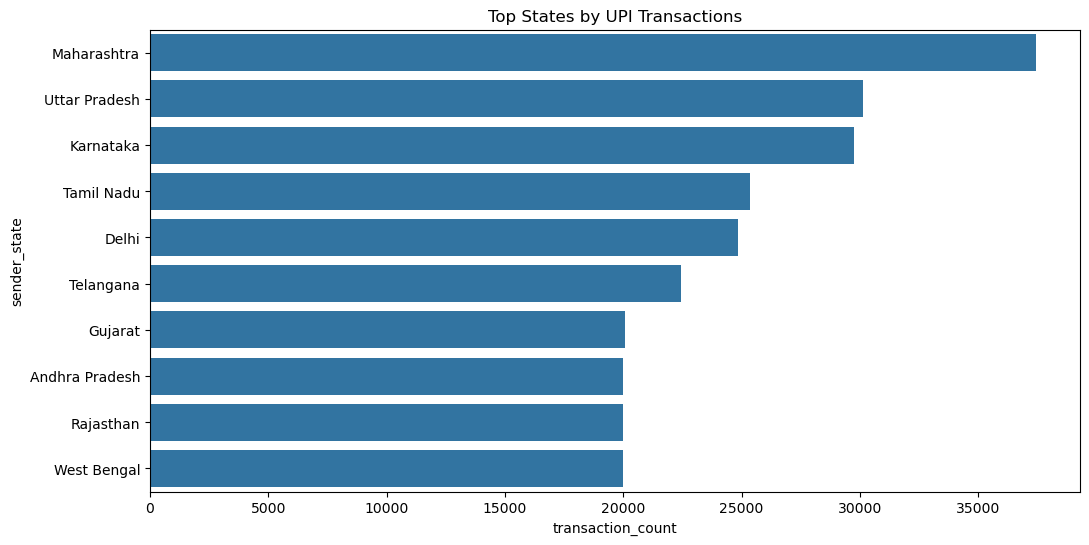

In [21]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_transactions.head(10),
    x="transaction_count",
    y="sender_state"
)

plt.title(
    "Top States by UPI Transactions"
)

plt.show()

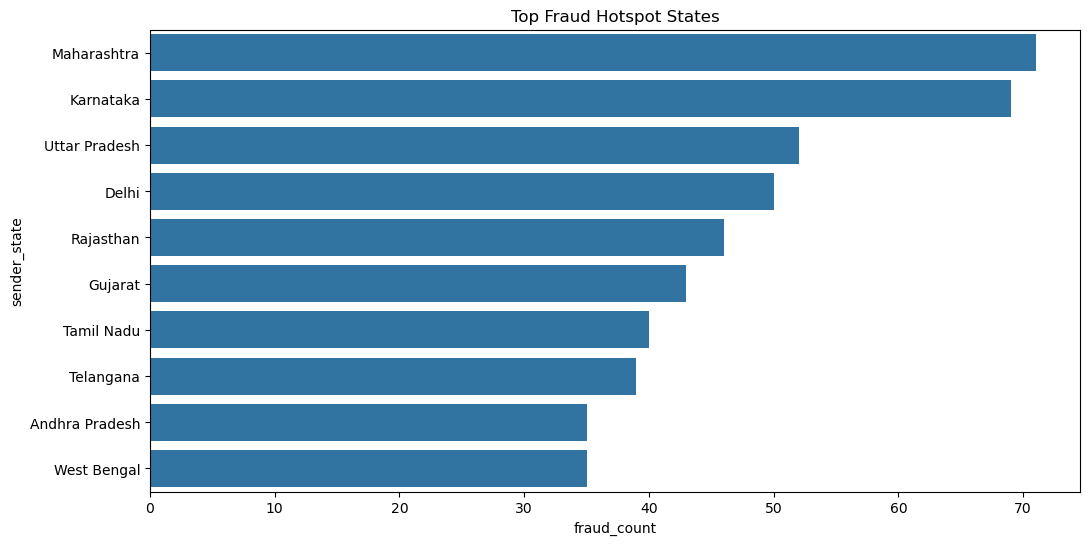

In [22]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=fraud_hotspots.head(10),
    x="fraud_count",
    y="sender_state"
)

plt.title(
    "Top Fraud Hotspot States"
)

plt.show()

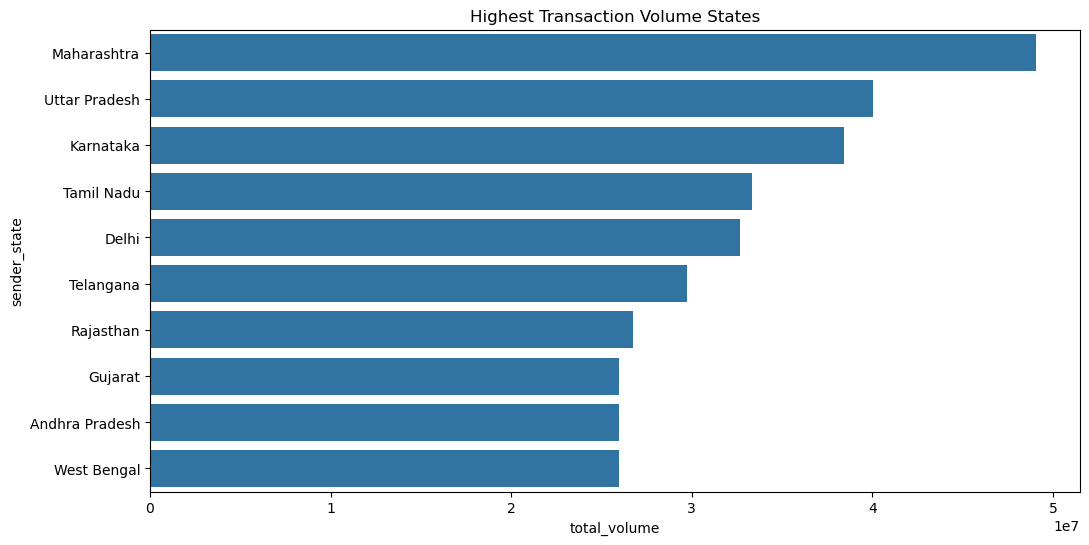

In [23]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=state_volume.head(10),
    x="total_volume",
    y="sender_state"
)

plt.title(
    "Highest Transaction Volume States"
)

plt.show()

In [24]:
geo_summary.to_csv(
    "../dataset/geo_summary.csv",
    index=False
)
fraud_hotspots.to_csv(
    "../dataset/fraud_hotspots.csv",
    index=False
)
geo_risk.to_csv(
    "../dataset/geo_risk_scores.csv",
    index=False
)
top_bank_state.to_csv(
    "../dataset/bank_penetration.csv",
    index=False
)